# **●	Task5 — Model Evaluation & Stability**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

from pyspark.sql import SparkSession

from pyspark.ml.classification import (
    LogisticRegressionModel,
    OneVsRestModel,
    NaiveBayesModel,
    RandomForestClassificationModel
)

from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator
)

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
spark = (
    SparkSession.builder
    .appName("Task5_Model_Evaluation")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .getOrCreate()
)

SEED = 42

print("Spark Started Successfully")

Spark Started Successfully


In [5]:
processed_df = spark.read.parquet(
    "/content/drive/MyDrive/7006SCN/processed_reviews"
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [6]:
processed_df.printSchema()

root
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- title: string (nullable = true)
 |-- review: string (nullable = true)
 |-- label: double (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- rawFeatures: vector (nullable = true)
 |-- features: vector (nullable = true)



In [7]:
processed_df.show(5)

+------+--------------------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+
|rating|                text|               title|              review|label|               words|      filtered_words|         rawFeatures|            features|
+------+--------------------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+
|   3.0|Depending on your...|it tastes exactly...|it tastes exactly...|  2.0|[it, tastes, exac...|[tastes, exactly,...|(10000,[36,274,28...|(10000,[36,274,28...|
|   5.0|Excellent value f...|   Excellent product|excellent product...|  0.0|[excellent, produ...|[excellent, produ...|(10000,[447,625,1...|(10000,[447,625,1...|
|   2.0|Love the scent of...|Product not what ...|product not what ...|  4.0|[product, not, wh...|[product, expecte...|(10000,[221,222,2...|(10000,[221,222,2...|
|   5.0|Gorgeous front la...

In [8]:
train_df, test_df = processed_df.randomSplit(
    [0.8,0.2],
    seed=SEED
)

print("Training Records :",train_df.count())

print("Testing Records :",test_df.count())

Training Records : 384943
Testing Records : 96361


In [9]:
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

In [10]:
lr_model = LogisticRegressionModel.load(
    "/content/drive/MyDrive/7006SCN/LR_Model"
)

print("Logistic Regression Loaded")

Logistic Regression Loaded


In [11]:
svm_model = OneVsRestModel.load(
    "/content/drive/MyDrive/7006SCN/LSVC_Model"
)

print("Linear SVM Loaded")

Linear SVM Loaded


In [12]:
nb_model = NaiveBayesModel.load(
    "/content/drive/MyDrive/7006SCN/NB_Model"
)

print("Naive Bayes Loaded")

Naive Bayes Loaded


In [13]:
rf_model = RandomForestClassificationModel.load(
    "/content/drive/MyDrive/7006SCN/RF_Model"
)

print("Random Forest Loaded")

Random Forest Loaded


In [14]:

lr_predictions = lr_model.transform(test_df)

svm_predictions = svm_model.transform(test_df)

nb_predictions = nb_model.transform(test_df)

rf_predictions = rf_model.transform(test_df)

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [15]:
lr_predictions.printSchema()

root
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- title: string (nullable = true)
 |-- review: string (nullable = true)
 |-- label: double (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- rawFeatures: vector (nullable = true)
 |-- features: vector (nullable = true)
 |-- rawPrediction: vector (nullable = true)
 |-- probability: vector (nullable = true)
 |-- prediction: double (nullable = false)



In [16]:
lr_predictions.select(

    "label",

    "prediction",

    "probability"

).show(10,truncate=False)

+-----+----------+-----------------------------------------------------------------------------------------------------+
|label|prediction|probability                                                                                          |
+-----+----------+-----------------------------------------------------------------------------------------------------+
|3.0  |0.0       |[0.5750282200369988,0.13520030083758183,0.10061531162122828,0.12062037026121183,0.06853579724297933] |
|3.0  |3.0       |[0.06675466425156408,0.1101735269035033,0.12324143749194903,0.6023645796585633,0.0974657916944201]   |
|3.0  |3.0       |[0.10204435893411248,0.04996216667628567,0.046788293458975,0.754651568084988,0.046553612845638706]   |
|3.0  |0.0       |[0.3226352045486764,0.16003158235931184,0.12217440181438058,0.3209612349338819,0.07419757634374936]  |
|3.0  |0.0       |[0.5929586284780003,0.18930173717920057,0.08246333871989557,0.08864315328114994,0.04663314234175351] |
|3.0  |0.0       |[0.45843125452

In [17]:
lr_predictions.cache()

svm_predictions.cache()

nb_predictions.cache()

rf_predictions.cache()

print("Prediction Data Cached")

Prediction Data Cached


In [18]:
print("LR Predictions :",lr_predictions.count())

print("SVM Predictions :",svm_predictions.count())

print("NB Predictions :",nb_predictions.count())

print("RF Predictions :",rf_predictions.count())

LR Predictions : 96361
SVM Predictions : 96361
NB Predictions : 96361
RF Predictions : 96361


In [19]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

In [20]:
def evaluate_model(predictions, model_name):

    pdf = predictions.select(
        "label",
        "prediction"
    ).toPandas()

    y_true = pdf["label"]
    y_pred = pdf["prediction"]

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    matrix = confusion_matrix(
        y_true,
        y_pred
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Report": report,
        "Confusion": matrix
    }

In [21]:
lr_eval = evaluate_model(
    lr_predictions,
    "Logistic Regression"
)

In [22]:
svm_eval = evaluate_model(
    svm_predictions,
    "Linear SVM"
)

In [23]:
nb_eval = evaluate_model(
    nb_predictions,
    "Naive Bayes"
)

In [24]:
rf_eval = evaluate_model(
    rf_predictions,
    "Random Forest"
)

In [25]:
metrics_table = pd.DataFrame([

    {
        "Model": lr_eval["Model"],
        "Accuracy": lr_eval["Accuracy"],
        "Precision": lr_eval["Precision"],
        "Recall": lr_eval["Recall"],
        "F1 Score": lr_eval["F1"]
    },

    {
        "Model": svm_eval["Model"],
        "Accuracy": svm_eval["Accuracy"],
        "Precision": svm_eval["Precision"],
        "Recall": svm_eval["Recall"],
        "F1 Score": svm_eval["F1"]
    },

    {
        "Model": nb_eval["Model"],
        "Accuracy": nb_eval["Accuracy"],
        "Precision": nb_eval["Precision"],
        "Recall": nb_eval["Recall"],
        "F1 Score": nb_eval["F1"]
    },

    {
        "Model": rf_eval["Model"],
        "Accuracy": rf_eval["Accuracy"],
        "Precision": rf_eval["Precision"],
        "Recall": rf_eval["Recall"],
        "F1 Score": rf_eval["F1"]
    }

])

metrics_table = metrics_table.round(4)

metrics_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6964,0.6504,0.6964,0.6342
1,Linear SVM,0.6994,0.6513,0.6994,0.6638
2,Naive Bayes,0.6248,0.6659,0.6248,0.6419
3,Random Forest,0.6320,0.3994,0.6320,0.4895


In [26]:
metrics_table.to_csv(
    "/content/drive/MyDrive/7006SCN/task5_metrics.csv",
    index=False
)

In [27]:
print("="*70)
print("LOGISTIC REGRESSION")
print("="*70)

print(
    classification_report(
        lr_predictions.select("label").toPandas(),
        lr_predictions.select("prediction").toPandas(),
        zero_division=0
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

         0.0       0.72      0.97      0.83     60898
         1.0       0.52      0.22      0.31     14768
         2.0       0.56      0.20      0.30      8430
         3.0       0.63      0.39      0.48      7306
         4.0       0.37      0.02      0.04      4959

    accuracy                           0.70     96361
   macro avg       0.56      0.36      0.39     96361
weighted avg       0.65      0.70      0.63     96361



In [28]:
print("="*70)
print("LOGISTIC REGRESSION")
print("="*70)

print(
    classification_report(
        lr_predictions.select("label").toPandas(),
        lr_predictions.select("prediction").toPandas(),
        zero_division=0
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

         0.0       0.72      0.97      0.83     60898
         1.0       0.52      0.22      0.31     14768
         2.0       0.56      0.20      0.30      8430
         3.0       0.63      0.39      0.48      7306
         4.0       0.37      0.02      0.04      4959

    accuracy                           0.70     96361
   macro avg       0.56      0.36      0.39     96361
weighted avg       0.65      0.70      0.63     96361



In [29]:
print("="*70)
print("NAIVE BAYES")
print("="*70)

print(
    classification_report(
        nb_predictions.select("label").toPandas(),
        nb_predictions.select("prediction").toPandas(),
        zero_division=0
    )
)

NAIVE BAYES
              precision    recall  f1-score   support

         0.0       0.86      0.75      0.80     60898
         1.0       0.36      0.40      0.38     14768
         2.0       0.28      0.36      0.32      8430
         3.0       0.45      0.58      0.51      7306
         4.0       0.18      0.24      0.21      4959

    accuracy                           0.62     96361
   macro avg       0.43      0.47      0.44     96361
weighted avg       0.67      0.62      0.64     96361



In [30]:
print("="*70)
print("RANDOM FOREST")
print("="*70)

print(
    classification_report(
        rf_predictions.select("label").toPandas(),
        rf_predictions.select("prediction").toPandas(),
        zero_division=0
    )
)

RANDOM FOREST
              precision    recall  f1-score   support

         0.0       0.63      1.00      0.77     60898
         1.0       0.00      0.00      0.00     14768
         2.0       0.00      0.00      0.00      8430
         3.0       0.00      0.00      0.00      7306
         4.0       0.00      0.00      0.00      4959

    accuracy                           0.63     96361
   macro avg       0.13      0.20      0.15     96361
weighted avg       0.40      0.63      0.49     96361



In [31]:
print("Logistic Regression")

print(lr_eval["Confusion"])

print()

print("Linear SVM")

print(svm_eval["Confusion"])

print()

print("Naive Bayes")

print(nb_eval["Confusion"])

print()

print("Random Forest")

print(rf_eval["Confusion"])

Logistic Regression
[[59222  1129   278   235    34]
 [10804  3185   510   243    26]
 [ 5093  1098  1720   454    65]
 [ 3912   267   202  2869    56]
 [ 3339   404   360   750   106]]

Linear SVM
[[56542  2393   950   658   355]
 [ 9084  3848  1148   445   243]
 [ 3351  1376  2443   880   380]
 [ 2059   336   470  4135   306]
 [ 1900   517   759  1360   423]]

Naive Bayes
[[45883  7776  3280  2013  1946]
 [ 5060  5892  2281   645   890]
 [ 1318  1804  3008  1058  1242]
 [  580   421   850  4229  1226]
 [  603   614  1178  1374  1190]]

Random Forest
[[60898     0     0     0     0]
 [14768     0     0     0     0]
 [ 8430     0     0     0     0]
 [ 7306     0     0     0     0]
 [ 4959     0     0     0     0]]


In [32]:

import matplotlib.pyplot as plt
import numpy as np

In [33]:
def plot_confusion_matrix(cm, model_name):

    classes = ["1", "2", "3", "4", "5"]

    fig, ax = plt.subplots(figsize=(8, 6))

    image = ax.imshow(cm)

    plt.colorbar(image)

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))

    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)

    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)

    plt.title(f"{model_name} Confusion Matrix", fontsize=14)

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=11
            )

    plt.tight_layout()

    return fig

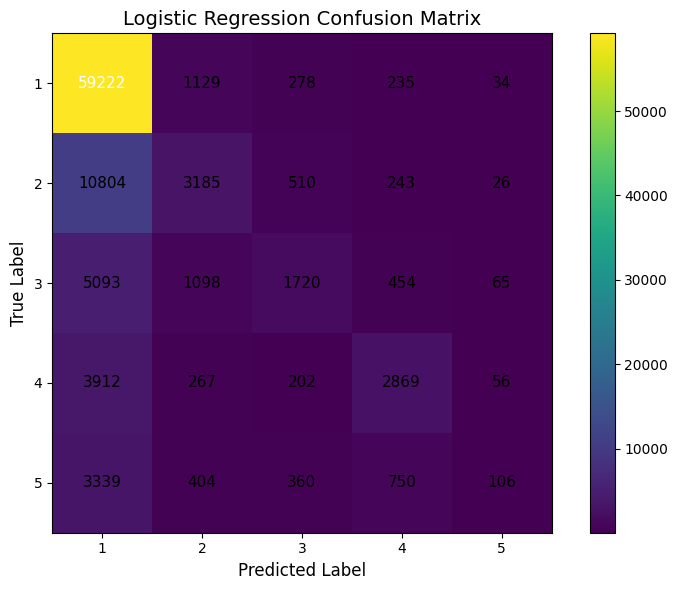

In [34]:
lr_fig = plot_confusion_matrix(
    lr_eval["Confusion"],
    "Logistic Regression"
)

plt.show()

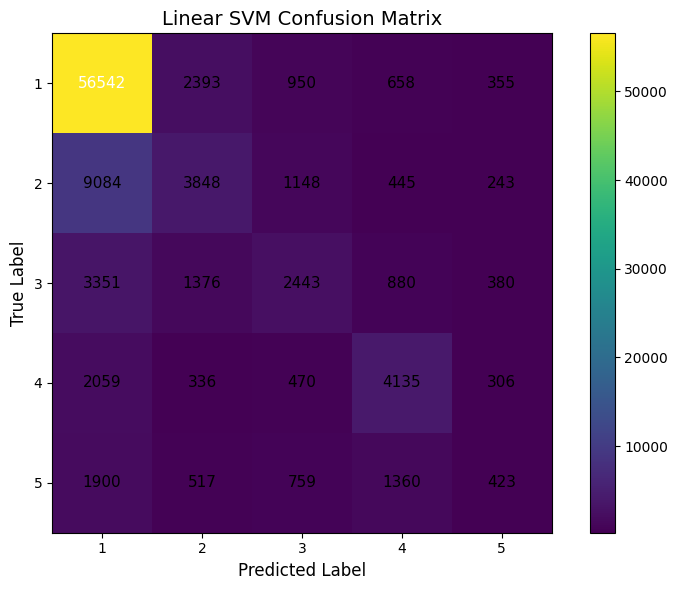

In [35]:
svm_fig = plot_confusion_matrix(
    svm_eval["Confusion"],
    "Linear SVM"
)

plt.show()

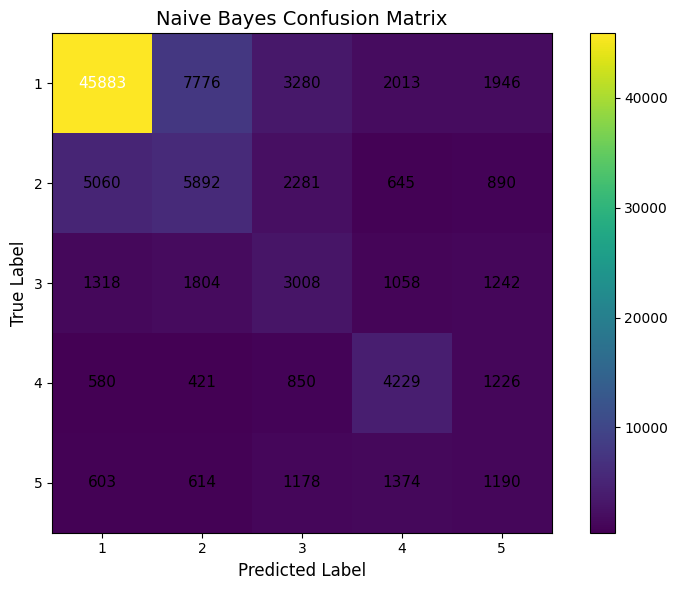

In [38]:
nb_fig = plot_confusion_matrix(
    nb_eval["Confusion"],
    "Naive Bayes"
)

plt.show()

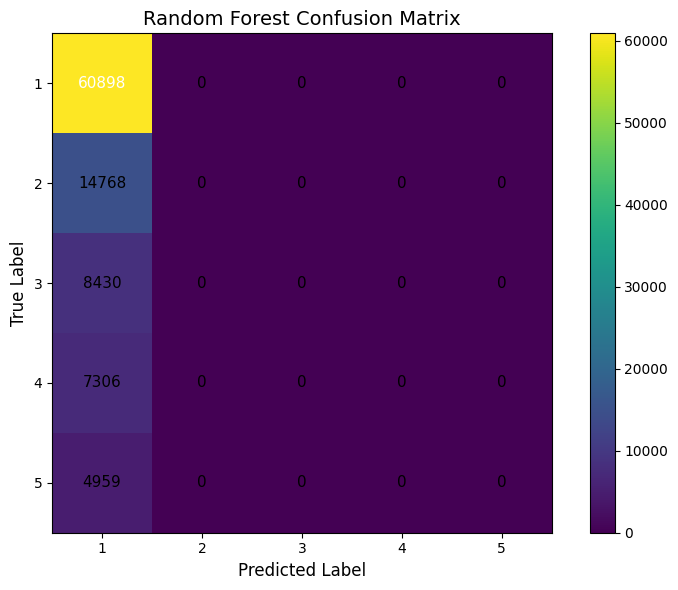

In [39]:
rf_fig = plot_confusion_matrix(
    rf_eval["Confusion"],
    "Random Forest"
)

plt.show()

# **ROC and Precision–Recall curves**

In [40]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

In [41]:
def prepare_multiclass_data(predictions):

    pdf = predictions.select(
        "label",
        "probability"
    ).toPandas()

    y_true = pdf["label"].astype(int).values

    y_score = np.vstack(
        pdf["probability"].apply(lambda x: x.toArray())
    )

    classes = np.sort(np.unique(y_true))

    y_true_bin = label_binarize(
        y_true,
        classes=classes
    )

    return y_true_bin, y_score, classes

In [42]:
lr_true, lr_score, classes = prepare_multiclass_data(
    lr_predictions
)

In [43]:
nb_true, nb_score, classes = prepare_multiclass_data(
    nb_predictions
)

In [44]:
rf_true, rf_score, classes = prepare_multiclass_data(
    rf_predictions
)

In [45]:
def plot_multiclass_roc(
    y_true,
    y_score,
    model_name
):

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    n_classes = y_true.shape[1]

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_true[:, i],
            y_score[:, i]
        )

        roc_auc[i] = auc(
            fpr[i],
            tpr[i]
        )

    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true.ravel(),
        y_score.ravel()
    )

    roc_auc["micro"] = auc(
        fpr["micro"],
        tpr["micro"]
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        linewidth=2,
        label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})"
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(model_name + " ROC Curve")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

    return roc_auc["micro"]

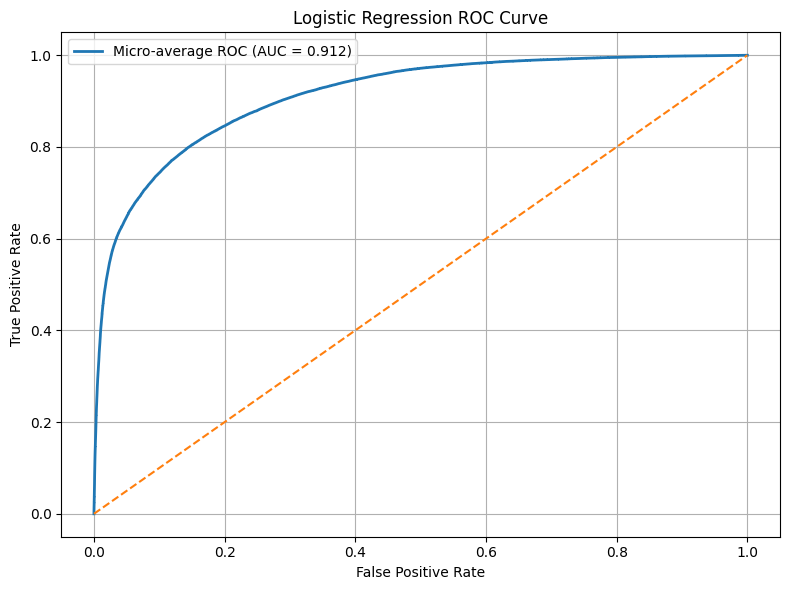

In [46]:
lr_auc = plot_multiclass_roc(
    lr_true,
    lr_score,
    "Logistic Regression"
)

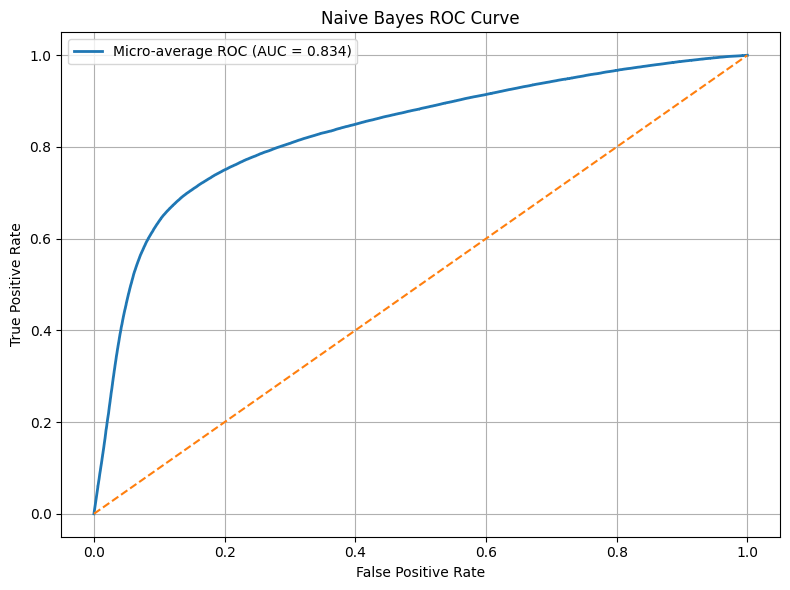

In [47]:
nb_auc = plot_multiclass_roc(
    nb_true,
    nb_score,
    "Naive Bayes"
)

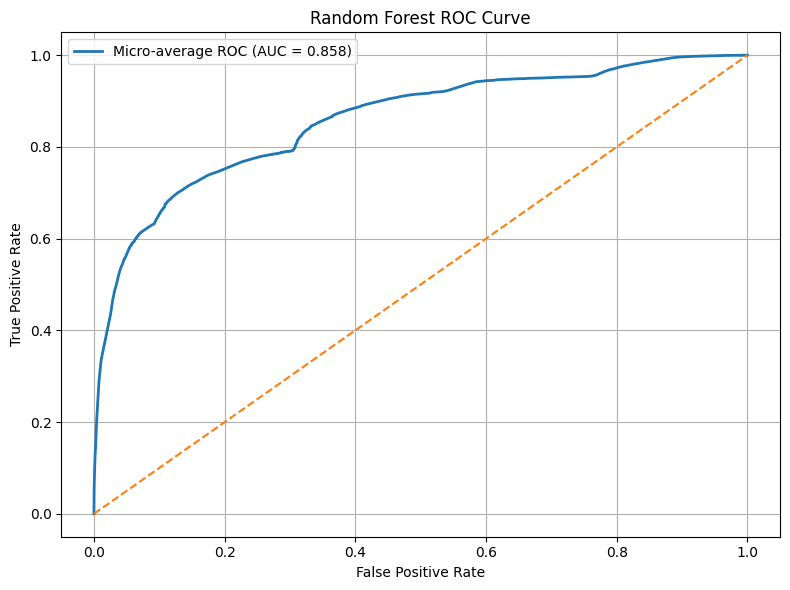

In [48]:
rf_auc = plot_multiclass_roc(
    rf_true,
    rf_score,
    "Random Forest"
)

In [49]:
def plot_multiclass_pr(
    y_true,
    y_score,
    model_name
):

    precision = dict()

    recall = dict()

    ap = dict()

    n_classes = y_true.shape[1]

    for i in range(n_classes):

        precision[i], recall[i], _ = precision_recall_curve(
            y_true[:, i],
            y_score[:, i]
        )

        ap[i] = average_precision_score(
            y_true[:, i],
            y_score[:, i]
        )

    precision["micro"], recall["micro"], _ = precision_recall_curve(
        y_true.ravel(),
        y_score.ravel()
    )

    ap["micro"] = average_precision_score(
        y_true,
        y_score,
        average="micro"
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        recall["micro"],
        precision["micro"],
        linewidth=2,
        label=f"Micro-average AP = {ap['micro']:.3f}"
    )

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.title(model_name + " Precision-Recall Curve")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

    return ap["micro"]

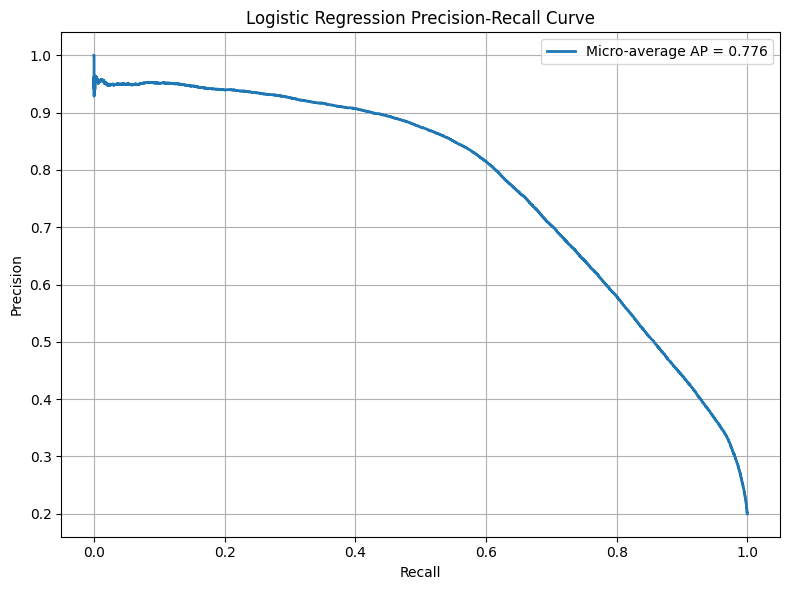

In [50]:
lr_ap = plot_multiclass_pr(
    lr_true,
    lr_score,
    "Logistic Regression"
)

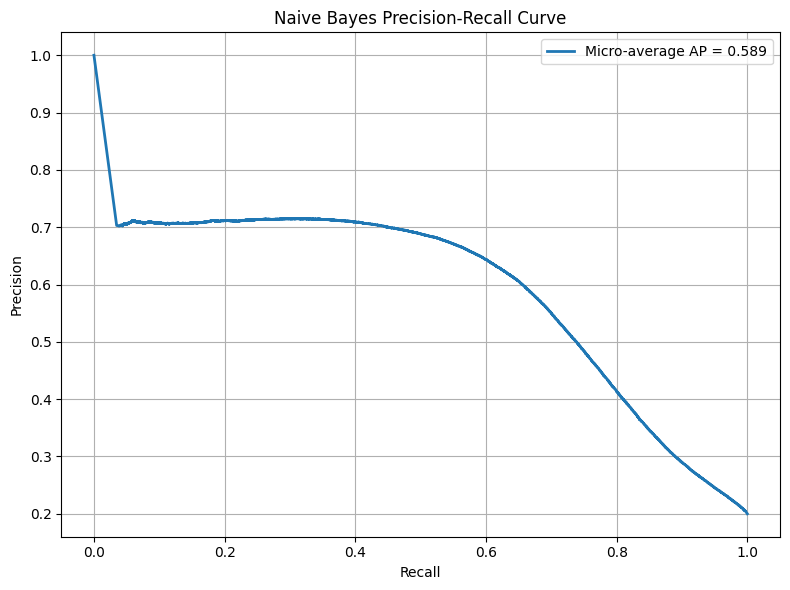

In [51]:
nb_ap = plot_multiclass_pr(
    nb_true,
    nb_score,
    "Naive Bayes"
)

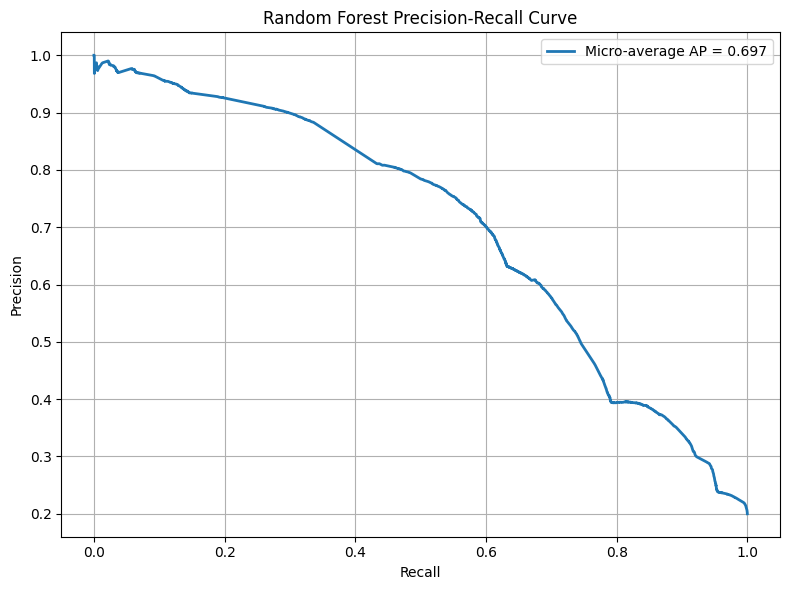

In [52]:
rf_ap = plot_multiclass_pr(
    rf_true,
    rf_score,
    "Random Forest"
)

In [53]:
roc_pr_summary = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],

    "ROC AUC":[
        lr_auc,
        nb_auc,
        rf_auc
    ],

    "Average Precision":[
        lr_ap,
        nb_ap,
        rf_ap
    ]

})

roc_pr_summary = roc_pr_summary.round(4)

roc_pr_summary

,Model,ROC AUC,Average Precision
0,Logistic Regression,0.9125,0.7757
1,Naive Bayes,0.8342,0.5888
2,Random Forest,0.8577,0.6970


In [54]:
roc_pr_summary.to_csv(
    "/content/drive/MyDrive/7006SCN/roc_pr_summary.csv",
    index=False
)

# **Perturbation Analysis**

In [63]:
import random
import numpy as np
import pandas as pd

from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql.functions import udf

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [64]:
def mask_features(vector, ratio):

    values = vector.toArray().copy()

    n = len(values)

    remove = int(n * ratio)

    indices = random.sample(range(n), remove)

    values[indices] = 0.0

    return Vectors.dense(values)

In [65]:
mask10 = udf(
    lambda v: mask_features(v, 0.10),
    VectorUDT()
)

mask20 = udf(
    lambda v: mask_features(v, 0.20),
    VectorUDT()
)

mask30 = udf(
    lambda v: mask_features(v, 0.30),
    VectorUDT()
)

In [66]:
perturb10 = test_df.withColumn(
    "features",
    mask10("features")
)

perturb20 = test_df.withColumn(
    "features",
    mask20("features")
)

perturb30 = test_df.withColumn(
    "features",
    mask30("features")
)

In [67]:
print("Original")

test_df.select("features").show(1, truncate=False)

print("10% Mask")

perturb10.select("features").show(1, truncate=False)

Original
+------------------------------------------------------------------------------------------------------+
|features                                                                                              |
+------------------------------------------------------------------------------------------------------+
|(10000,[594,815,6010,9605],[4.317550446017787,1.9489085834193474,3.077084779955292,2.186906193763135])|
+------------------------------------------------------------------------------------------------------+
only showing top 1 row
10% Mask
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [68]:
def evaluate_accuracy(model, dataframe):

    prediction = model.transform(dataframe)

    pdf = prediction.select(
        "label",
        "prediction"
    ).toPandas()

    return accuracy_score(
        pdf["label"],
        pdf["prediction"]
    )

### **Interpretability with LIME (Surrogate Model Approach)**
We will train a scikit-learn Logistic Regression model on a sample of the data to act as a surrogate for explanation purposes.

In [71]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=fab3533182012b49be6f716001e651c51314196ba426049859f65919319bee21
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [76]:
# ============================================================
# LIME Explainability - Train Surrogate Model
# ============================================================

from lime.lime_text import LimeTextExplainer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
import pandas as pd

# ------------------------------------------------------------
# Sample data for explanation - Using random sample to avoid single-class error
# ------------------------------------------------------------

sample_data = (
    test_df
    .select("review", "label")
    .sample(withReplacement=False, fraction=0.05, seed=42) # Randomly sample 5% of test data
    .limit(2000)
    .toPandas()
)

print("Sample Size:", len(sample_data))
print("Label Distribution in Sample:")
print(sample_data['label'].value_counts())

# ------------------------------------------------------------
# Create TF-IDF + Logistic Regression Pipeline
# ------------------------------------------------------------

vectorizer = TfidfVectorizer(
    max_features=10000
)

classifier = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000,
    random_state=42
)

pipeline = make_pipeline(
    vectorizer,
    classifier
)

# ------------------------------------------------------------
# Train Surrogate Model
# ------------------------------------------------------------

pipeline.fit(
    sample_data["review"],
    sample_data["label"]
)

print("\nSurrogate Model Trained Successfully")

# ------------------------------------------------------------
# Training Accuracy
# ------------------------------------------------------------

train_accuracy = pipeline.score(
    sample_data["review"],
    sample_data["label"]
)

print(f"Training Accuracy : {train_accuracy:.4f}")

Sample Size: 2000
Label Distribution in Sample:
label
0.0    1216
1.0     308
2.0     195
3.0     167
4.0     114
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Surrogate Model Trained Successfully
Training Accuracy : 0.7650


In [80]:
# ============================================================
# LIME Explainability
# ============================================================

# ------------------------------------------------------------
# Class Labels
# ------------------------------------------------------------

label_mapping = {
    0: "Rating 1",
    1: "Rating 2",
    2: "Rating 3",
    3: "Rating 4",
    4: "Rating 5"
}

class_names = list(label_mapping.values())

explainer = LimeTextExplainer(
    class_names=class_names
)

# ------------------------------------------------------------
# Select Review
# ------------------------------------------------------------

idx = 10

text_instance = sample_data.iloc[idx]["review"]

true_label = int(sample_data.iloc[idx]["label"])

predicted_probs = pipeline.predict_proba([text_instance])[0]
predicted_label = int(np.argmax(predicted_probs))

print("="*70)
print("LIME EXPLAINABILITY")
print("="*70)

print("Review Index     :", idx)

print("Actual Label     :", label_mapping[true_label])

print("Predicted Label  :", label_mapping[predicted_label])

print()

print("Review Text:")

print(text_instance[:700])

print()

# ------------------------------------------------------------
# Generate Explanation
# ------------------------------------------------------------

exp = explainer.explain_instance(
    text_instance,
    pipeline.predict_proba,
    num_features=10,
    top_labels=1
)

# Get the label that was actually explained
explained_label = exp.available_labels()[0]

# ------------------------------------------------------------
# Display Explanation
# ------------------------------------------------------------

exp.show_in_notebook(text=True, labels=[explained_label])

# ------------------------------------------------------------
# Feature Importance Table
# ------------------------------------------------------------

lime_features = pd.DataFrame(
    exp.as_list(label=explained_label),
    columns=[
        "Word / Phrase",
        "Contribution"
    ]
)

print(f"\nTop Influential Words for {label_mapping[explained_label]}")

display(lime_features)

# ------------------------------------------------------------
# Save Outputs
# ------------------------------------------------------------

lime_features.to_csv(
    "/content/drive/MyDrive/7006SCN/LIME_Feature_Importance.csv",
    index=False
)

exp.save_to_file(
    "/content/drive/MyDrive/7006SCN/LIME_Explanation.html"
)

print()

print("LIME feature importance saved.")

print("LIME HTML report saved.")

LIME EXPLAINABILITY
Review Index     : 10
Actual Label     : Rating 4
Predicted Label  : Rating 4

Review Text:
not buying this again  did not work for me  the product color is brown  i do  like clear better  does not hold as i though  i will  not buy it again  but it does not mean it is bad




Top Influential Words for Rating 4


,Word / Phrase,Contribution
0,not,0.239753
1,it,-0.053182
2,but,-0.049298
3,again,0.040522
4,did,0.037145
5,work,0.029531
6,bad,0.028284
7,color,-0.021619
8,as,-0.019618
9,better,-0.017803



LIME feature importance saved.
LIME HTML report saved.


In [81]:
# ============================================================
# LIME for Multiple Reviews - Fixed KeyError
# ============================================================

review_indices = [5, 10, 25]

for idx in review_indices:

    text = sample_data.iloc[idx]["review"]

    true_label = int(sample_data.iloc[idx]["label"])

    # Predict probabilities to find the top class
    probs = pipeline.predict_proba([text])[0]
    predicted_label = int(np.argmax(probs))

    explanation = explainer.explain_instance(
        text,
        pipeline.predict_proba,
        num_features=10,
        top_labels=1
    )

    # Dynamically get the label that LIME explained
    explained_label = explanation.available_labels()[0]

    print("="*80)

    print(f"Review {idx}")

    print("Actual Label    :", label_mapping[true_label])

    print("Predicted Label :", label_mapping[predicted_label])

    display(
        pd.DataFrame(
            explanation.as_list(label=explained_label),
            columns=[
                "Word / Phrase",
                "Contribution"
            ]
        )
    )

Review 5
Actual Label    : Rating 4
Predicted Label : Rating 4


,Word / Phrase,Contribution
0,star,0.253625
1,out,0.019587
2,broke,0.012563
3,me,-0.003167
4,one,-0.001773


Review 10
Actual Label    : Rating 4
Predicted Label : Rating 4


,Word / Phrase,Contribution
0,not,0.239877
1,it,-0.054672
2,but,-0.048885
3,again,0.038971
4,did,0.034608
5,bad,0.028856
6,work,0.028065
7,color,-0.020096
8,better,-0.018916
9,as,-0.016878


Review 25
Actual Label    : Rating 4
Predicted Label : Rating 4


,Word / Phrase,Contribution
0,damaged,0.084072
1,and,-0.070010
2,amazing,-0.065333
3,all,0.055486
4,were,0.054217
5,package,0.051832
6,bought,0.049200
7,amazon,0.046916
8,was,0.041603
9,from,0.035416
